---
**Load Datasets**
---

---

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # go up one level from /notebooks
sys.path.append(str(project_root))

from src.setup import ensure_project_root, load_file, load_dta_with_col

In [ ]:
# Auto-detect project root and store it
root = ensure_project_root()
print("Project Root:", root)

# Load NTL, NDVI, and Built-up data sets
ntl_ndvi = load_file("Maha_NTL_NDVI_2014_20.csv", root)
builtup = load_file("Maha_BuiltUp_2015_2020.csv", root)

Project Root: C:\Users\SHARVARI\NTL_EPI_Analysis


In [ ]:
print("\nNTL_NDVI Head:")
ntl_ndvi.head()

---
**Satellite Data: Clean and Process**
---
Three satellite datasets were selected for analysis - VIIRS-DNB, MODIS NDVI, and GHSL.
The administrative boundaries for Maharshtra's districts were obtained from FAO GAUL 2015 Level-2 dataset.

The VIIRS-DNB 2014-2024 was selected for Night-Time Lights (NTL) information, as the VIIRS-DNB was found to be superior to its predecessor DMSP-OLS.
The MODIS NDVI 2014-2024 provides the Normalized Difference Vegetation Index.
The GHSL BUILT-S 2015 and 2020 provides absolute built-up surface area (m. sq.)

---

In [5]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import shape

from src.clean_data import keep_columns, std_cols, make_numeric, geo_to_geom, create_geo_df

**NTL & NDVI Data**

In [6]:
df_n = ntl_ndvi.copy()

# Keep required columns
cols_to_keep = ["NDVI_mean", "NTL_mean", "district", "year", ".geo"]
df_n = keep_columns(dataframe=df_n, columns=cols_to_keep)

# Standardize text columns
text_cols = ["district", "state"]
df_n = std_cols(dataframe=df_n, columns=text_cols)

# Make numeric columns
float_cols = ["NDVI_mean", "NTL_mean"]
df_n = make_numeric(dataframe=df_n, columns=float_cols, dtype=float)
df_n = make_numeric(dataframe=df_n, columns=["year"], dtype='Int64')

# Sort by date
df_n["date"] = pd.to_datetime(df_n["year"].astype(str) + "-01-01")
df_n = df_n.sort_values("date")

# Checking for duplicates
dups = df_n.groupby(["district","year"]).size().reset_index(name="count").query("count>1")
print("district-year duplicates:", len(dups))

district-year duplicates: 0


**Generate shapefile dataframe for maps**

In [7]:
gdf = create_geo_df(df_n) 
gdf_area = gdf.to_crs("EPSG:6933")  # World Mercator-like equal area
gdf["area_sqkm"] = gdf_area.geometry.area / 1e6

GeoDataFrame created with CRS: EPSG:4326


**Built-up Data**

In [8]:
df_b = builtup.copy()

# Keep required columns
cols_to_keep = ["mean", "district", "year"]
df_b = keep_columns(dataframe=df_b, columns=cols_to_keep)

df_b = df_b.rename(columns={"mean": "Built_mean"})

# Standardize text columns
text_cols = ["district", "state"]
df_b = std_cols(dataframe=df_b, columns=text_cols)

# Make numeric columns
float_cols = ["Built_mean"]
df_b = make_numeric(dataframe=df_b, columns=float_cols, dtype=float)
df_b = make_numeric(dataframe=df_b, columns=["year"], dtype='Int64')

# Checking for duplicates
dups = df_b.groupby(["district","year"]).size().reset_index(name="count").query("count>1")
print("district-year duplicates:", len(dups))

district-year duplicates: 0


In [9]:
# MERGE with NTL/NDVI GeoDF gdf 
gdf_built = gdf.merge(df_b, on=["district", "year"], how="left")
print("Merged rows:", len(gdf))
#gdf.head()

Merged rows: 385


---
**Satellite Data: Visualize**
---

---

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

from src.visualize_data import plot_choropleth, plot_choropleth_log

**Mapping Average NTL**

Number of districts: 35


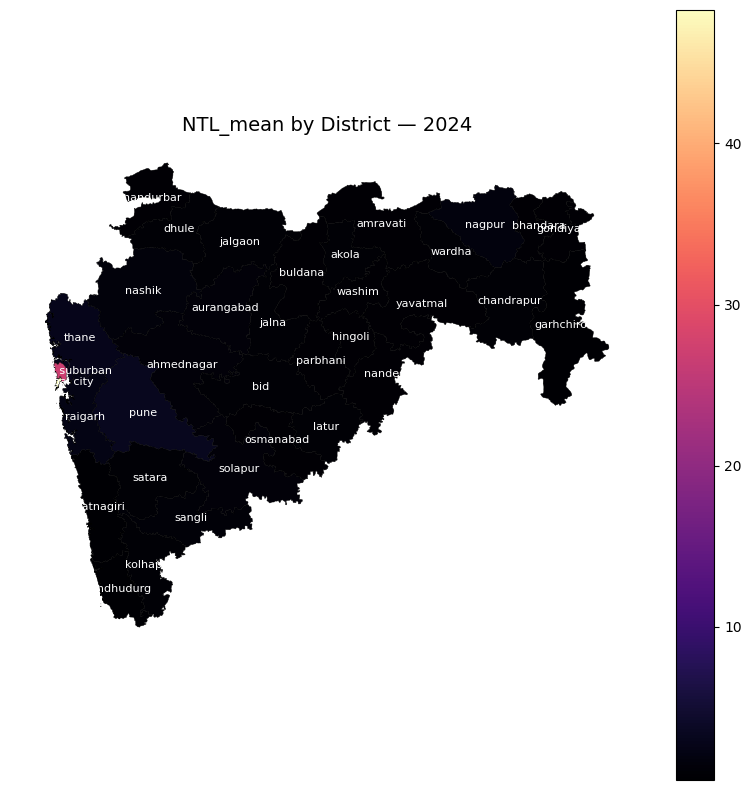

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'NTL_mean by District — 2024'}>)

In [11]:
# Specify year (between 2014-2024)
plot_choropleth(gdf, 2024)

Number of districts: 35


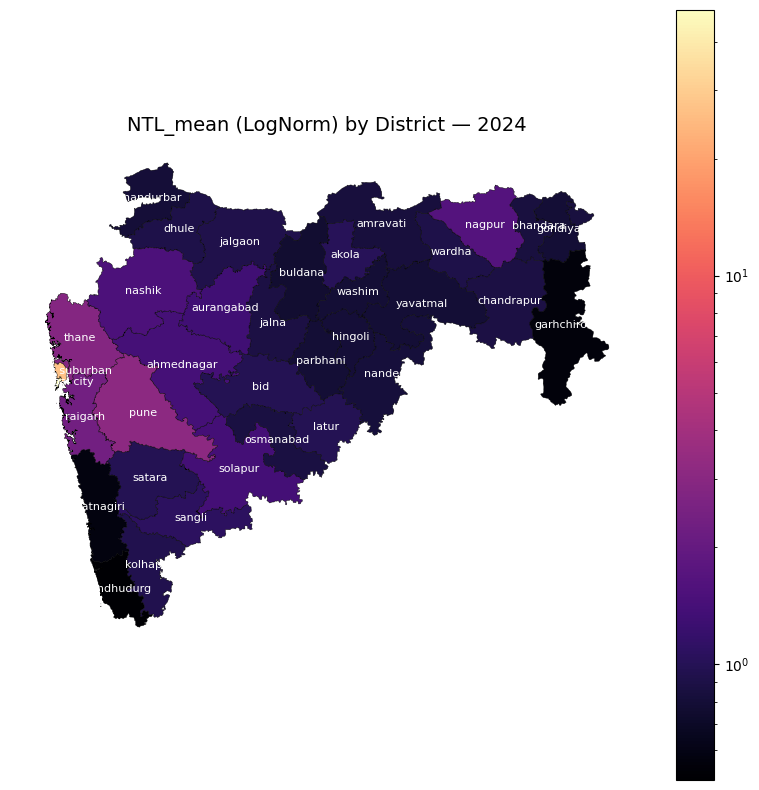

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'NTL_mean (LogNorm) by District — 2024'}>)

In [12]:
# Specify year (between 2014-2024)
plot_choropleth_log(gdf, 2024)

**Description**

The above maps display mean NTL intensity across districts in Maharashtra. This can be used as a proxy for economic activity, urbanization, and electrification.

The first map appears almost entirely black due to a few highly urbanized areas (such as Mumbai, Pune, Thane) which have extremely high NTL values. This helps highlight urban concentration. The second map displays logarithmic transformation of mean NTL values which helps reveal spatial variation across districts.

High NTL intensity districts include Mumbai, Thane, Pune and low NTL intensity districts include Gadchiroli, Sindhudurg, Ratnagiri. NTL intensity follows an urban hierarchy, with clear gradations from metropolitan centers to rural peripheries.

---

**Mapping Average NDVI**

Number of districts: 35


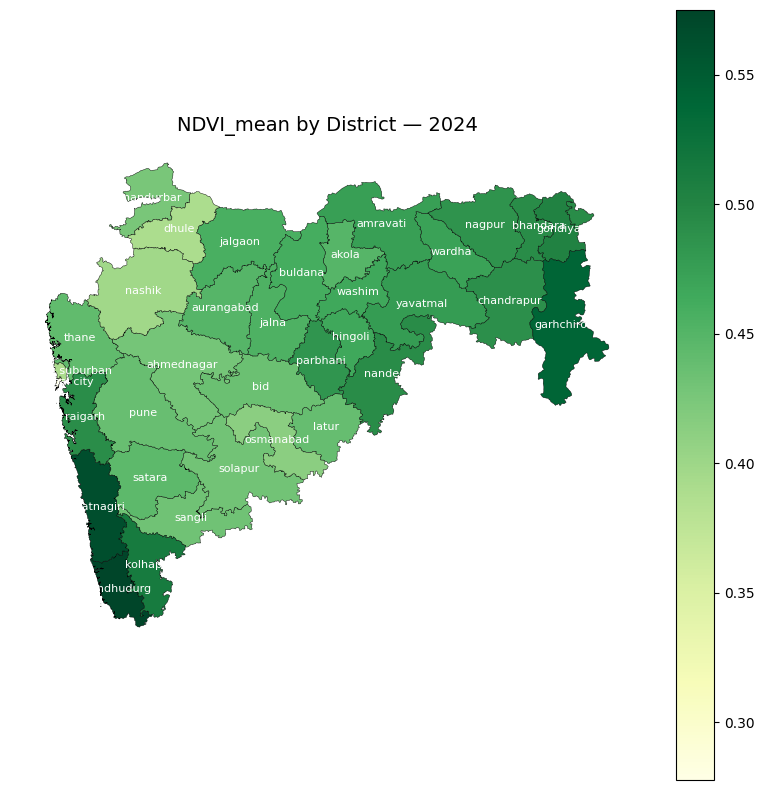

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'NDVI_mean by District — 2024'}>)

In [15]:
# Specify year (between 2014-2024)
plot_choropleth(gdf, 2024, column="NDVI_mean", cmap="YlGn")

**Description**

This map shows vegetation density across Maharashtra using the Normalized Difference Vegetation Index (NDVI). Higher NDVI values (darker green) indicate denser, healthier vegetation. 
The spatial pattern reveals that eastern districts (Gadchiroli, Chandrapur, Gondia) and the Western Ghats region (Sindhudurg, Kolhapur, Raigad, Ratnagiri) have the highest vegetation cover, while the Deccan Plateau districts in central Maharashtra (Ahmednagar, Pune, Solapur, Aurangabad) show lower vegetation density, reflecting the semi-arid climate and agricultural land use patterns. Urban districts like Mumbai and Thane also display lower NDVI values due to built-up areas replacing natural vegetation.

---
**Year-on-Year Trends**

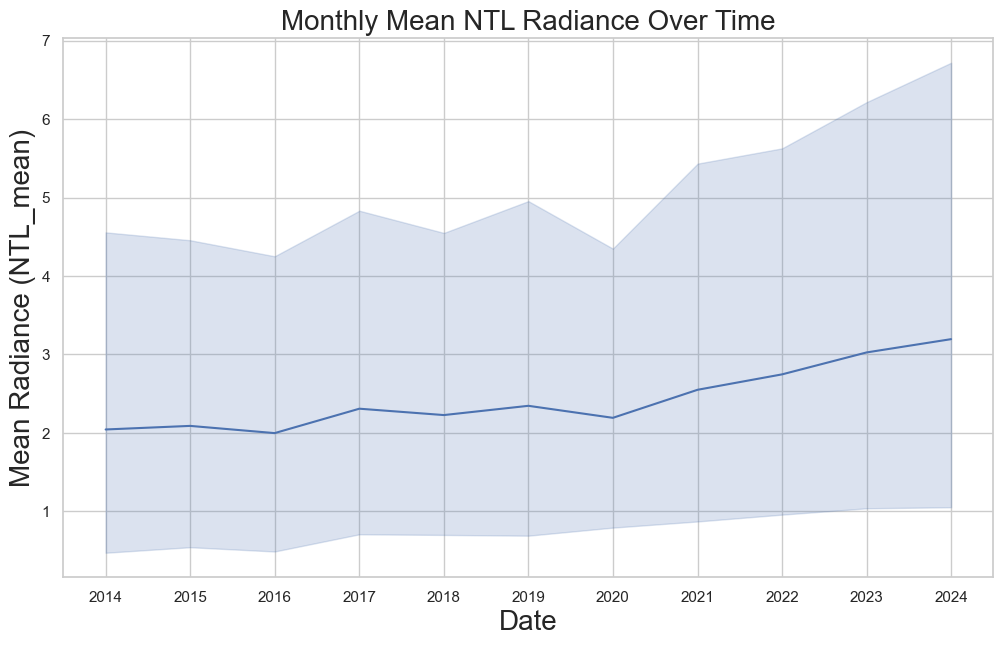

In [16]:
# NTL
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=df_n,
    x="date",
    y="NTL_mean",
    ax=ax
)

ax.set_ylabel("Mean Radiance (NTL_mean)", fontsize=20)
ax.set_xlabel("Date", fontsize=20)
ax.set_title("Monthly Mean NTL Radiance Over Time", fontsize=20)

plt.show()

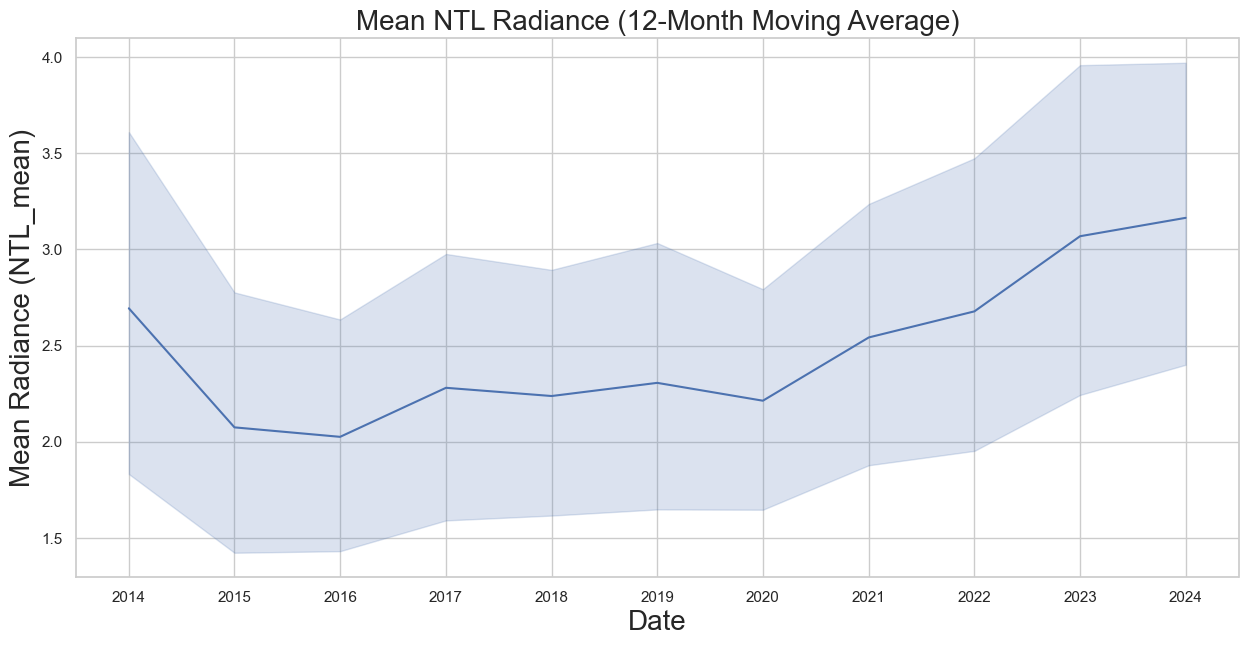

In [17]:
# NTL 12-month moving average
window = 12

df_ntl_roll = (
    df_n[["date", "NTL_mean"]]     
    .set_index("date")             
    .rolling(window)
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(
    data=df_ntl_roll,
    x="date",
    y="NTL_mean",
    ax=ax
)

ax.set_ylabel("Mean Radiance (NTL_mean)", fontsize=20)
ax.set_xlabel("Date", fontsize=20)
ax.set_title(f"Mean NTL Radiance ({window}-Month Moving Average)", fontsize=20)

plt.show()

**Description**

The first graph shows considerable month-to-month variability in mean NTL intensity with a gradual upward trend from 2014 to 2024. The wide confidence band (shaded area) indicates substantial seasonal variation. 
The 12-month moving average in the second graph smooths out seasonal fluctuations and short-term volatility, making it easier to identify the underlying long-term trend in mean NTL intensity. This reveals a recent surge in mean NTL intensity suggesting rapid urbanization, infrastructure expansion, and economic recovery post-pandemic.

---

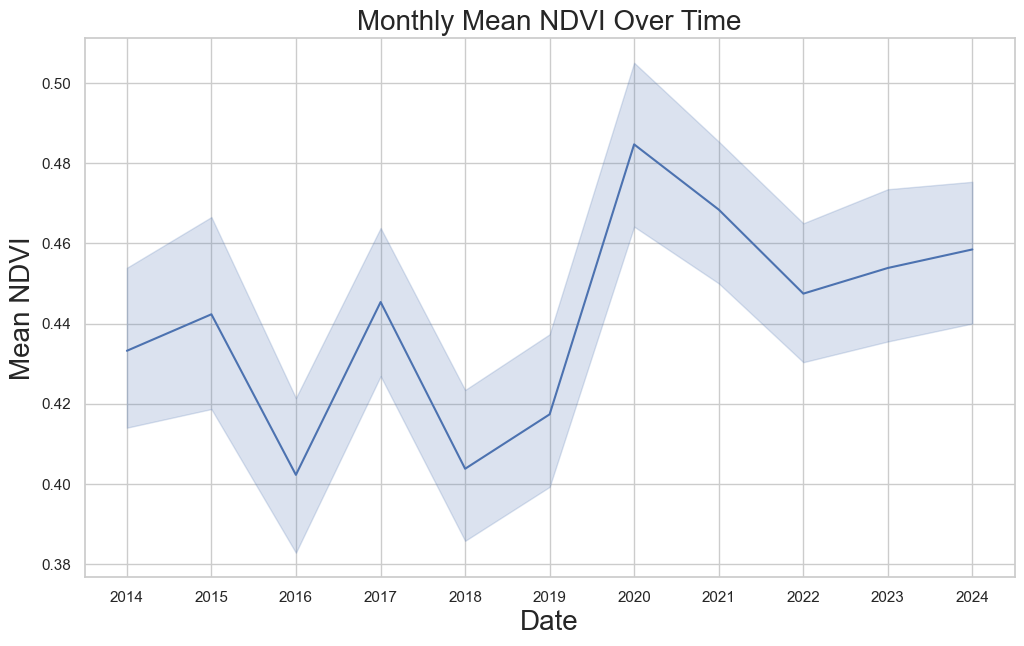

In [18]:
# NDVI
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=df_n,
    x="date",
    y="NDVI_mean",
    ax=ax
)

ax.set_ylabel("Mean NDVI", fontsize=20)
ax.set_xlabel("Date", fontsize=20)
ax.set_title("Monthly Mean NDVI Over Time", fontsize=20)

plt.show()

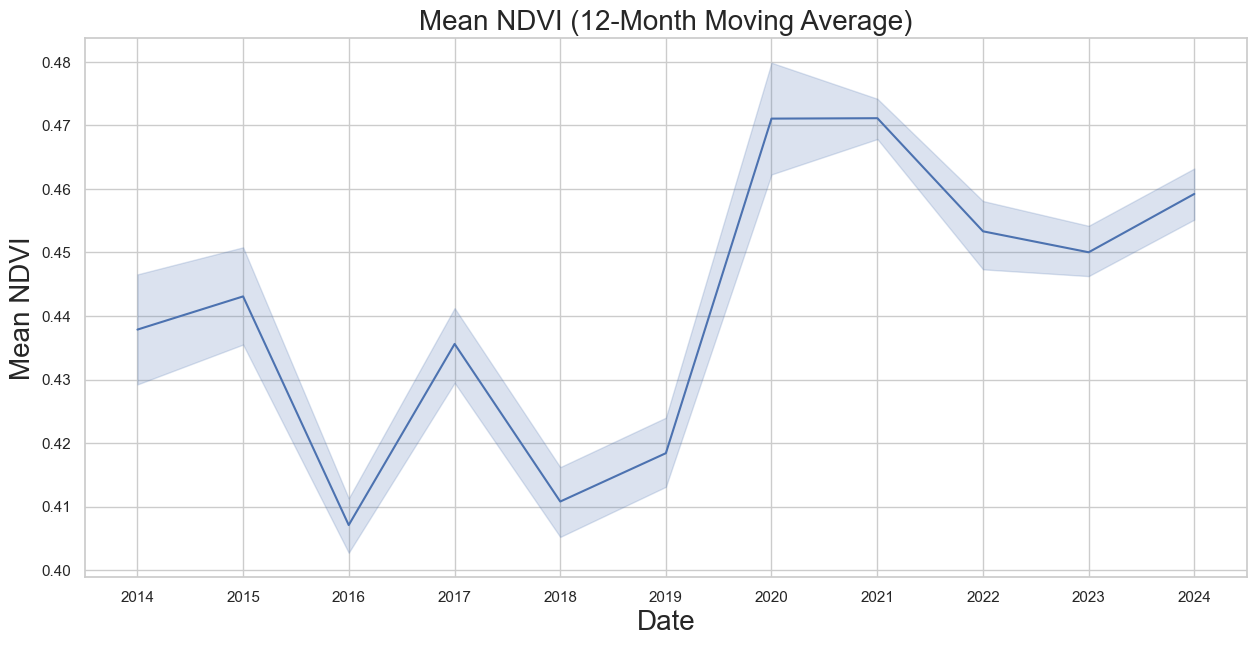

In [19]:
# NDVI 12-month moving average
window = 12 

df_roll = (
    df_n[["date", "NDVI_mean"]]     
    .set_index("date")            
    .rolling(window)
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(
    data=df_roll,
    x="date",
    y="NDVI_mean",
    ax=ax
)

ax.set_ylabel("Mean NDVI", fontsize=20)
ax.set_xlabel("Date", fontsize=20)
ax.set_title(f"Mean NDVI ({window}-Month Moving Average)", fontsize=20)

plt.show()

**Description**

The first graph displays pronounced seasonal oscillations in NDVI and the peaks could be attributed to above-average monsoon rainfall and agricultural expansion. The second graph reflects similar fluctuations. The overall pattern indicates NDVI is highly sensitive to annual climate variability rather than showing a consistent long-term trend with steady urbanization as captured by NTL data. 

---

**Built-up Change Heatmap**

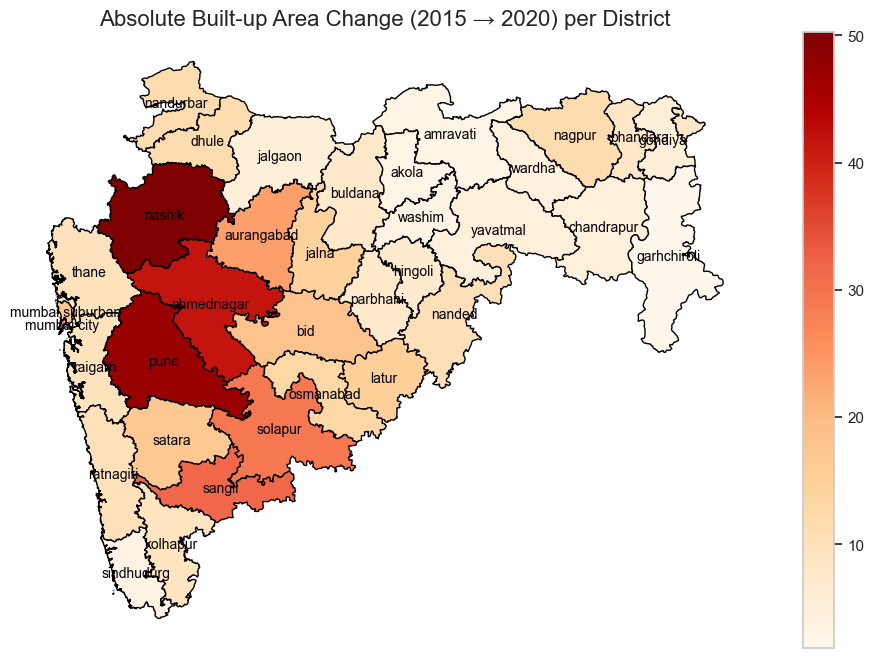

In [20]:
# Sort by year
df_b = df_b.sort_values(by=["district", "year"])

# Pivot to get 2015 and 2020 separately
df_pivot = df_b.pivot_table(index=["district"], columns="year", values="Built_mean").reset_index()
df_pivot["builtup_change"] = df_pivot[2020] - df_pivot[2015]

# Merge with GeoDataFrame (take one geometry per district)
gdf_unique = gdf_built.drop_duplicates(subset=["district"])
gdf_change = gdf_unique.merge(df_pivot[["district", "builtup_change"]],
                              on=["district"], how="left")

# Plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf_change.plot(column="builtup_change", cmap="OrRd", legend=True, edgecolor="black", ax=ax)
ax.set_title("Absolute Built-up Area Change (2015 → 2020) per District", fontsize=16)
ax.axis("off")

for idx, row in gdf_change.iterrows():
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["district"],       
            fontsize=10,
            color="black",        
            ha="center",
            va="center"
        )
    
plt.show()

**Description**

This map displays the absolute increase in built-up area (in square meters) across Maharashtra's districts between 2015 and 2020, reflecting rapid urbanization and infrastructure expansion during this period. The highest growth districts include Pune and Nashik followed by Ahmednagar. The lower growth districts include Sindhudurg, Gadchiroli, Akola, etc.